# Download Model

In [2]:
import urllib.request

url = 'https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_heavy/float16/latest/pose_landmarker_heavy.task'
urllib.request.urlretrieve(url, 'pose_landmarker.task')
print('Downloaded!')

Downloaded!


# Raw- no PTM

In [2]:
from tasks.cmj import extract_jump_keypoints, ts_jump_height


hip, toe = extract_jump_keypoints('media/jump.mp4')

# Flip y axis (0 is at top of frame)
toe_y = toe[:,1].max() - toe[:,1]
jump_height = ts_jump_height(toe_y, fps=30)
print(f'Jump height: {jump_height} cm')

Jump height: 7.97 cm


# Using Gravit PTM

1  px equals 7.3 mm


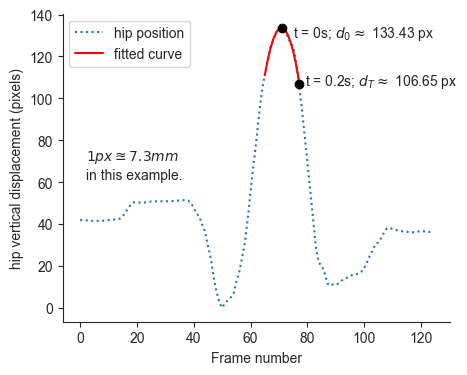

Scale: 7.32 mm per pixel
Calibrated jump height: 58.35 cm


In [3]:
from utilities.utils import flip_axis, get_flight_time
import utilities.PTM as PTM
import numpy as np

hip_flipped = flip_axis(hip)
toe_flipped = flip_axis(toe)


mm_px = PTM.mm_per_px(hip_flipped[:, 1], fps=30, verbose=True, plot=True)
print(f'Scale: {mm_px:.2f} mm per pixel')


toe_y_mm = toe_flipped[:,1] * mm_px
jump_height_cm = (max(toe_y_mm) - np.mean(toe_y_mm[:15])) / 10
print(f'Calibrated jump height: {jump_height_cm:.2f} cm')

In [4]:
hip_y_mm = hip_flipped[:,1] * mm_px
jump_height_cm = (max(hip_y_mm) - np.mean(hip_y_mm[:15])) / 10
print(f'Hip-based jump height: {jump_height_cm:.2f} cm')

Hip-based jump height: 67.11 cm


In [5]:
from posedata import PoseData

data = PoseData("keypoints/cmj/P03_CMJ_FRONT.txt")
df = data.df
print(df.shape)
print(df.head())

ImportError: cannot import name 'utils' from 'scripts' (c:\Users\dylan\Documents\Projects\machine_vision_media_pipe\venv\Lib\site-packages\scripts\__init__.py)

In [ ]:
import os
print(os.getcwd())
print(os.listdir())

c:\Users\dylan\Documents\Projects\machine_vision_media_pipe
['._posedata.py', 'keypoints', 'media', 'mm_to_px.pdf', 'posedata.py', 'pose_landmarker.task', 'PTM.py', 'requirements.txt', 'tasks', 'test.ipynb', 'utils.py', 'venv', '__pycache__']


In [ ]:
print(os.listdir('keypoints/cmj'))

['._.DS_Store', '._P03_CMJBL_FRONT.txt', '._P03_CMJBL_FRONT_world.txt', '._P03_CMJUL_FRONT.txt', '._P03_CMJUL_FRONT_world.txt', '._P04_CMJ_BL_FRONT.txt', '._P04_CMJ_BL_FRONT_world.txt', '._P04_CMJ_UL_FRONT.txt', '._P04_CMJ_UL_FRONT_world.txt', '._P05_CMJ_BL_FRONT.txt', '._P05_CMJ_BL_FRONT_world.txt', '._P05_CMJ_UL_FRONT.txt', '._P05_CMJ_UL_FRONT_world.txt', '._P06_CMJ_BL_FRONT.txt', '._P06_CMJ_BL_FRONT_world.txt', '._P06_CMJ_UL_FRONT.txt', '._P06_CMJ_UL_FRONT_world.txt', '._P07_CMJ_BL_FRONT.txt', '._P07_CMJ_BL_FRONT_world.txt', '._P07_CMJ_UL_FRONT.txt', '._P07_CMJ_UL_FRONT_world.txt', '._P08_CMJ_BL_FRONT.txt', '._P08_CMJ_BL_FRONT_world.txt', '._P08_CMJ_UL_FRONT.txt', '._P08_CMJ_UL_FRONT_world.txt', '._P09_CMJ_BL_FRONT.txt', '._P09_CMJ_BL_FRONT_world.txt', '._P09_CMJ_UL_FRONT.txt', '._P09_CMJ_UL_FRONT_world.txt', '._P10_CMJ_BL_FRONT.txt', '._P10_CMJ_BL_FRONT_world.txt', '._P10_CMJ_UL_FRONT.txt', '._P10_CMJ_UL_FRONT_world.txt', '._P11_CMJ_BL_FRONT.txt', '._P11_CMJ_BL_FRONT_world.txt', '.

In [ ]:
from posedata import PoseData

data = PoseData("keypoints/cmj/._P03_CMJBL_FRONT.txt")
df = data.df
print(df.shape)
print(df.head())

ValueError: could not convert string to float: '\x00\x05\x16\x07\x00\x02\x00\x00Mac OS X        \x00\x02\x00\x00\x00\t\x00\x00\x002\x00\x00\x00‰\x00\x00\x00\x02\x00\x00\x00»\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00ATTR\x00\x00\x00\x00\x00\x00\x00»\x00\x00\x00˜\x00\x00\x00#\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x01\x00\x00\x00˜\x00\x00\x00#\x00\x00\x15com.apple.quarantine\x00q/0082;6a1ece6a;Screen\\x20Sharing;\x00'

In [ ]:
print(os.listdir('_keypoints/cmj'))

FileNotFoundError: [WinError 3] The system cannot find the path specified: '_keypoints/cmj'

In [ ]:
from posedata import PoseData

data = PoseData("keypoints/cmj/P03_CMJBL_FRONT.txt")
df = data.df
print(df.shape)
print(df.head())

(1122, 99)
     NOSE_x    NOSE_y    NOSE_z  LEFT_EYE_INNER_x  LEFT_EYE_INNER_y  \
0  0.535330  0.437397 -0.367922          0.537271          0.431432   
1  0.536976  0.437902 -0.450852          0.539004          0.431558   
2  0.537189  0.438178 -0.473603          0.539343          0.431613   
3  0.537328  0.438453 -0.474797          0.539588          0.431708   
4  0.537347  0.438608 -0.472516          0.539658          0.431754   

   LEFT_EYE_INNER_z  LEFT_EYE_x  LEFT_EYE_y  LEFT_EYE_z  LEFT_EYE_OUTER_x  \
0         -0.343890    0.539744    0.431466   -0.343888          0.541989   
1         -0.425557    0.541473    0.431634   -0.425534          0.543666   
2         -0.449324    0.541896    0.431704   -0.449299          0.544188   
3         -0.450777    0.542207    0.431812   -0.450754          0.544564   
4         -0.448565    0.542304    0.431862   -0.448544          0.544703   

   ...  LEFT_HEEL_z  RIGHT_HEEL_x  RIGHT_HEEL_y  RIGHT_HEEL_z  \
0  ...     0.184785      0.472876 